# Quantum Tilted Loss in QAOA and HEA for MaxCut

This notebook explores the performance of the **Quantum Tilted Loss Function** in solving the MaxCut problem using the **Quantum Approximate Optimization Algorithm (QAOA)** and a **Hardware Efficient Ansatz (HEA)**.

### 1. Mathematical Background
The standard loss function in VQA is the expectation value of the Hamiltonian:
$$\mathcal{L}_{std}(\theta) = \bra{\psi(\theta)} H \ket{\psi(\theta)}$$

The **Quantum Tilted Loss Function** is defined as:
$$\mathcal{L}_\gamma(H,\rho(\theta)) := - \frac{1}{\gamma} \log \text{tr} \left( e^{- \gamma H} \rho(\theta) \right)$$
where $\gamma$ is a real parameter. As $\gamma \to 0$, it recovers the standard expectation value. For $\gamma > 0$, it penalizes high-energy (sub-optimal) states more heavily, potentially accelerating convergence to the ground state.

### 2. Goal
1. Compare Standard Loss vs Tilted Loss for MaxCut with QAOA.
2. Test Tilted Loss with Hardware Efficient Ansatz.
3. Compare the algorithm performance with different fixed values of $\gamma$ (0.1, 5, 10, 20, 100).
4. Investigate the effect of tuning $\gamma$ using different schedules (Linear, Sigmoid, Exponential, Logarithmic).

In [3]:
%%capture

# Comment this out if you don't want to install pennylane from this notebook
!pip install pennylane

# Comment this out if you don't want to install matplotlib from this notebook
!pip install matplotlib

In [22]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time
import math
from dataclasses import dataclass

from IPython.display import display
import pennylane as qml
from pennylane import numpy as qnp

import networkx as nx

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)

In [32]:
@dataclass(frozen=True)
class ObjectiveSpec:
    name: str
    kind: str
    alpha: float | None = None
    gamma: float | None = None
    gamma_start: float | None = None
    gamma_end: float | None = None
    schedule: str | None = None
    color: str = "C0"


MAIN_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=10.0", "qtl", gamma=10.0, color="#2ca02c"),
    ObjectiveSpec("QTL gamma=20.0", "qtl", gamma=20.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=20,
        schedule="linear",
        color="#9467bd",
    ),
]


SCHEDULE_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=5.0", "qtl", gamma=5.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=10,
        schedule="linear",
        color="#9467bd",
    ),
    ObjectiveSpec(
        "QTL schedule sigmoid",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=10,
        schedule="sigmoid",
        color="#e377c2",
    ),
    ObjectiveSpec(
        "QTL reverse linear",
        "qtl_schedule",
        gamma_start=10,
        gamma_end=0,
        schedule="linear",
        color="#7f7f7f",
    ),
]

FIXED_GAMMA_GRID = [0.5, 5, 20, 100, 200]
GAMMA_GRID_OBJECTIVES = [
    ObjectiveSpec(f"QTL gamma={gamma}", "qtl", gamma=gamma, color=plt.cm.viridis(i / (len(FIXED_GAMMA_GRID) - 1)))
    for i, gamma in enumerate(FIXED_GAMMA_GRID)
] + [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0,
        gamma_end=5,
        schedule="linear",
        color="#9467bd",
    ),
]

CURVE_OBJECTIVES = ["Expectation", "QTL gamma=2.0", "QTL gamma=5.0", "QTL schedule linear"]
HARD_OBJECTIVES = ["Expectation", "QTL gamma=5.0", "QTL schedule linear"]
BUDGET_OBJECTIVES = ["Expectation", "QTL gamma=5.0", "QTL schedule linear"]

ALL_OBJECTIVES = {
    obj.name: obj
    for obj in MAIN_OBJECTIVES + SCHEDULE_OBJECTIVES + GAMMA_GRID_OBJECTIVES
}
OBJECTIVE_COLORS = {name: obj.color for name, obj in ALL_OBJECTIVES.items()}

FAST_CONFIG = {
    # "graph_families": ["regular3"],
    "graph_families": ["erdos_renyi"],
    "sizes": [8],
    # "sizes": [8, 10, 12],
    # "depths": [1, 2, 3],
    "depths": [2],
    # "depths": [3],
    # "seeds": [0],
    "seeds": [0, 1, 2, 3, 4],
    "lr": 0.18,
    "lr_decay_power": 0.55,
    "lr_decay_offset": 6.0,
    "beta_mom": 0.7,
    "gamma_lr_penalty": 0.02,
    "grad_clip": 2.5,
    "steps": 80,
    "shots": 256,
    "gradient_probes": 4,
    "target_ratio": 0.99,
    "curve_n": 8,
    "summary_n": 8,
    "summary_p": 2,
    "budget_n": 8,
    "budget_p": 2,
    "budget_seeds": [0, 1, 2],
    "budget_shots_grid": [64, 128, 256, 512],
    "budget_total_shots": 15360,
    "gamma_grid_n": 8,
    "gamma_grid_p": 2,
    "schedule_n": 8,
    "schedule_p": 2,
}

FULL_CONFIG = {
    **FAST_CONFIG,
    "graph_families": ["erdos_renyi"],
    # "graph_families": ["regular3", "erdos_renyi"],
    "seeds": list(range(8)),
    "steps": 80,
    "shots": 256,
    "gradient_probes": 8,
    "budget_seeds": list(range(8)),
}

RUN_CONFIG = FAST_CONFIG
print("Running config:", RUN_CONFIG)

EXACT_SMALL_SCALE_CONFIG = {
    **FAST_CONFIG,
    "sizes": [8],
    "depths": [2],
    "seeds": [0],
    "steps": 80,
    "shots": 128,
}


Running config: {'graph_families': ['erdos_renyi'], 'sizes': [8], 'depths': [2], 'seeds': [0, 1, 2, 3, 4], 'lr': 0.18, 'lr_decay_power': 0.55, 'lr_decay_offset': 6.0, 'beta_mom': 0.7, 'gamma_lr_penalty': 0.02, 'grad_clip': 2.5, 'steps': 80, 'shots': 256, 'gradient_probes': 4, 'target_ratio': 0.99, 'curve_n': 8, 'summary_n': 8, 'summary_p': 2, 'budget_n': 8, 'budget_p': 2, 'budget_seeds': [0, 1, 2], 'budget_shots_grid': [64, 128, 256, 512], 'budget_total_shots': 15360, 'gamma_grid_n': 8, 'gamma_grid_p': 2, 'schedule_n': 8, 'schedule_p': 2}


## Task 1: QAOA Comparison (Standard vs CVaR vs Tilted)

We calculate the exact maximum cuts of the graphs using brute force sampling search, which is denoted by $c_{max}$. Then we use QAOA algorithm to solve the maxcut problem and return us with the final bit string that corresponds to a cut $c_{obtained}$. Then we evaluate the approximation ratio of this obtained cut compared to the exact maximum cut, and plot the figure.

In [26]:
# Code to generate the graph
def make_graph(n, family, seed):
    if family == "regular3":
        graph = nx.random_regular_graph(3, n, seed=seed)
    elif family == "erdos_renyi":
        p = min(0.45, 3.0 / (n - 1))
        graph = nx.gnp_random_graph(n, p, seed=seed)
        while not nx.is_connected(graph):
            seed += 1
            graph = nx.gnp_random_graph(n, p, seed=seed)
    else:
        raise ValueError(f"Unknown graph family: {family}")
    return graph


def basis_states(n):
    return np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)], dtype=int)


def cut_values_from_samples(samples, edges):
    samples = np.asarray(samples, dtype=int)
    cuts = np.zeros(samples.shape[0], dtype=int)
    for u, v in edges:
        cuts += (samples[:, u] != samples[:, v]).astype(int)
    return cuts


def exact_cut_data(n, edges):
    basis = basis_states(n)
    cuts = cut_values_from_samples(basis, edges)
    return basis, cuts.astype(float), float(cuts.max())

[(0, 1), (0, 4), (1, 3), (1, 4), (2, 3), (2, 6), (3, 5), (3, 6), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
[ 0.  3.  5.  6.  3.  4.  6.  5.  4.  5.  7.  6.  7.  6.  8.  5.  4.  7.
  7.  8.  5.  6.  6.  5.  8.  9.  9.  8.  9.  8.  8.  5.  2.  5.  5.  6.
  5.  6.  6.  5.  6.  7.  7.  6.  9.  8.  8.  5.  4.  7.  5.  6.  5.  6.
  4.  3.  8.  9.  7.  6.  9.  8.  6.  3.  3.  6.  8.  9.  6.  7.  9.  8.
  5.  6.  8.  7.  8.  7.  9.  6.  5.  8.  8.  9.  6.  7.  7.  6.  7.  8.
  8.  7.  8.  7.  7.  4.  5.  8.  8.  9.  8.  9.  9.  8.  7.  8.  8.  7.
 10.  9.  9.  6.  5.  8.  6.  7.  6.  7.  5.  4.  7.  8.  6.  5.  8.  7.
  5.  2.  2.  5.  7.  8.  5.  6.  8.  7.  4.  5.  7.  6.  7.  6.  8.  5.
  6.  9.  9. 10.  7.  8.  8.  7.  8.  9.  9.  8.  9.  8.  8.  5.  4.  7.
  7.  8.  7.  8.  8.  7.  6.  7.  7.  6.  9.  8.  8.  5.  6.  9.  7.  8.
  7.  8.  6.  5.  8.  9.  7.  6.  9.  8.  6. 

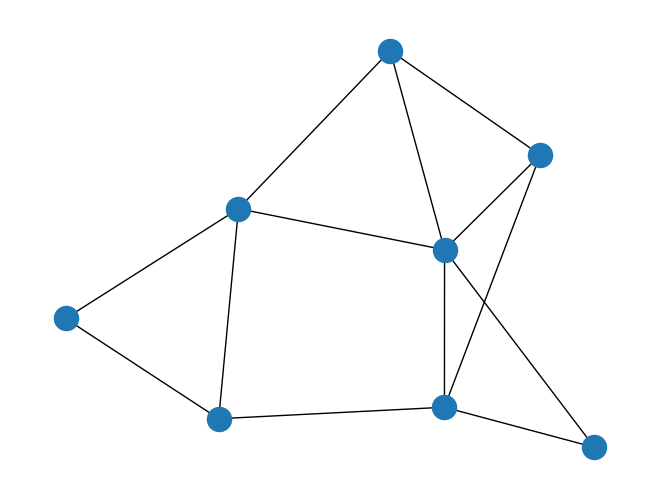

In [15]:
n = 8
family = 'erdos_renyi'
# Set random seed for reproducibility
# seed = np.random.seed(42)
G = make_graph(n, family, 1)
nx.draw(G)

edges = sorted(G.edges())
print(edges)

a,b,c = exact_cut_data(n, edges)
print(a)
print(b)
print(c)

Define the Hamiltonian

In [16]:
# # Define a small graph for MaxCut (4-node ring)
# nodes = 4
# edges = [(0, 1), (1, 2), (2, 3), (3, 0)]


# Hamiltonian: H = sum 0.5 * (Zi * Zj - 1) for (i,j) in edges
# Minimizing this minimizes edges with same spin, thus maximizing the cut.
coeffs = [0.5] * len(edges) + [-0.5] * len(edges)
obs = [qml.PauliZ(i) @ qml.PauliZ(j) for i, j in edges] + [qml.Identity(i) for i in range(len(edges))]
H = qml.Hamiltonian(coeffs, obs)

print(f'Hamiltonian for {n}-node MaxCut:\n', H)

Hamiltonian for 8-node MaxCut:
 0.5 * (Z(0) @ Z(1)) + 0.5 * (Z(0) @ Z(4)) + 0.5 * (Z(1) @ Z(3)) + 0.5 * (Z(1) @ Z(4)) + 0.5 * (Z(2) @ Z(3)) + 0.5 * (Z(2) @ Z(6)) + 0.5 * (Z(3) @ Z(5)) + 0.5 * (Z(3) @ Z(6)) + 0.5 * (Z(4) @ Z(6)) + 0.5 * (Z(4) @ Z(7)) + 0.5 * (Z(5) @ Z(6)) + 0.5 * (Z(5) @ Z(7)) + 0.5 * (Z(6) @ Z(7)) + -0.5 * I(0) + -0.5 * I(1) + -0.5 * I(2) + -0.5 * I(3) + -0.5 * I(4) + -0.5 * I(5) + -0.5 * I(6) + -0.5 * I(7) + -0.5 * I(8) + -0.5 * I(9) + -0.5 * I(10) + -0.5 * I(11) + -0.5 * I(12)


Define the loss functions.

In [27]:
def qtl_loss_from_distribution(probs, losses, gamma):
    probs = qml.math.asarray(probs)
    losses = qml.math.asarray(losses)
    if gamma is None or abs(gamma) < 1e-12:
        return qml.math.dot(probs, losses)
    loss_min = qml.math.min(losses)
    shifted = losses - loss_min
    weighted = qml.math.sum(probs * qml.math.exp(-gamma * shifted))
    return loss_min - qml.math.log(weighted) / gamma


def _sigmoid_frac(frac):
    base = 1.0 / (1.0 + np.exp(-12.0 * (frac - 0.5)))
    low = 1.0 / (1.0 + np.exp(6.0))
    high = 1.0 / (1.0 + np.exp(-6.0))
    return float((base - low) / (high - low))


def scheduled_gamma(spec, step, total_steps):
    if spec.kind != "qtl_schedule":
        return spec.gamma
    if total_steps <= 1:
        return float(spec.gamma_end)
    frac = step / (total_steps - 1)
    if spec.schedule == "linear":
        schedule_frac = frac
    elif spec.schedule == "sigmoid":
        schedule_frac = _sigmoid_frac(frac)
    elif spec.schedule == "piecewise":
        if frac < 0.5:
            schedule_frac = 0.2 * frac / 0.5
        else:
            schedule_frac = 0.2 + 0.8 * (frac - 0.5) / 0.5
    else:
        raise ValueError(f"Unknown schedule: {spec.schedule}")
    return float(spec.gamma_start + schedule_frac * (spec.gamma_end - spec.gamma_start))


def objective_loss_from_distribution(probs, cuts, c_max: float, spec: ObjectiveSpec, step: int, total_steps: int):
    losses = c_max - qml.math.asarray(cuts)
    if spec.kind == "expectation":
        return qml.math.dot(probs, losses)
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss_from_distribution(probs, losses, gamma)


Define the QAOA circuit and optimizer.

In [28]:
def make_qaoa_prob_qnode(
    n: int,
    edges: list[tuple[int, int]],
    *,
    shots: int | None,
    device_seed: int,
):
    dev = qml.device("default.qubit", wires=n, seed=int(device_seed))

    @qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
    def base_circuit(params):
        p = len(params) // 2
        gammas = params[:p]
        betas = params[p:]
        for wire in range(n):
            qml.Hadamard(wires=wire)
        for gamma, beta in zip(gammas, betas):
            for u, v in edges:
                qml.IsingZZ(2.0 * gamma, wires=[u, v])
            for wire in range(n):
                qml.RX(2.0 * beta, wires=wire)
        return qml.probs(wires=range(n))

    if shots is None:
        return base_circuit
    return qml.set_shots(base_circuit, shots=shots)


def summarize_probs(probs: np.ndarray, cuts: np.ndarray, c_max: float) -> dict[str, float]:
    optimal_mask = cuts == c_max
    support_mask = probs > 1e-12
    best_cut = float(np.max(cuts[support_mask])) if np.any(support_mask) else float(np.max(cuts))
    return {
        "mean_cut": float(np.dot(probs, cuts)),
        "mean_ratio": float(np.dot(probs, cuts) / c_max),
        "best_cut": best_cut,
        "best_ratio": float(best_cut / c_max),
        "optimal_mass": float(probs[optimal_mask].sum()),
    }


def optimize_parameter(
    circuit,
    cuts: np.ndarray,
    c_max: float,
    init_params: np.ndarray,
    spec: ObjectiveSpec,
    config: dict,
    *,
    exact: bool,
):
    params = qnp.array(init_params, requires_grad=True)
    momentum = np.zeros_like(np.asarray(init_params, dtype=float))
    best_cut_so_far = -np.inf
    evals_per_step = 2 * len(init_params) + 2
    history = []

    for step in range(config["steps"]):
        def loss_fn(theta):
            wrapped = qnp.mod(theta, 2 * np.pi)
            probs = circuit(wrapped)
            return objective_loss_from_distribution(probs, cuts, c_max, spec, step, config["steps"])

        grad = np.asarray(qml.grad(loss_fn)(params), dtype=float)
        grad_norm = float(np.linalg.norm(grad))
        if grad_norm > config["grad_clip"]:
            grad = grad * (config["grad_clip"] / grad_norm)

        momentum = config["beta_mom"] * momentum + (1.0 - config["beta_mom"]) * grad
        step_lr = config["lr"] / ((step + 1 + config["lr_decay_offset"]) ** config["lr_decay_power"])
        gamma_now = scheduled_gamma(spec, step, config["steps"])
        if gamma_now is not None and config["gamma_lr_penalty"] > 0.0:
            step_lr = step_lr / (1.0 + config["gamma_lr_penalty"] * abs(gamma_now))

        updated = np.mod(np.asarray(params, dtype=float) - step_lr * momentum, 2 * np.pi)
        params = qnp.array(updated, requires_grad=True)

        probs = np.asarray(circuit(params), dtype=float)
        metrics = summarize_probs(probs, cuts, c_max)
        best_cut_so_far = max(best_cut_so_far, metrics["best_cut"])
        history.append(
            {
                "iteration": step + 1,
                "loss": float(loss_fn(params)),
                "mean_cut": metrics["mean_cut"],
                "mean_ratio": metrics["mean_ratio"],
                "best_ratio_step": metrics["best_ratio"],
                "best_ratio_so_far": float(best_cut_so_far / c_max),
                "best_cut_so_far": int(best_cut_so_far),
                "optimal_mass": metrics["optimal_mass"],
                "gamma": np.nan if gamma_now is None else float(gamma_now),
                "lr": float(step_lr),
                "grad_norm": float(np.linalg.norm(grad)),
                "circuit_evals": int((step + 1) * evals_per_step),
                "shots_used": np.nan if exact else int((step + 1) * evals_per_step * config["shots"]),
            }
        )

    return params, pd.DataFrame(history)


def run_single_setting(
    graph_family: str,
    n: int,
    p: int,
    seed: int,
    spec: ObjectiveSpec,
    config: dict,
    *,
    exact: bool,
):
    graph = make_graph(n, graph_family, seed)
    edges = sorted(graph.edges())
    _, cuts, c_max = exact_cut_data(n, edges)

    init_rng = np.random.default_rng(10_000 * n + 100 * p + seed)
    init_params = init_rng.uniform(0.0, np.pi, size=2 * p)
    circuit = make_qaoa_prob_qnode(
        n,
        edges,
        shots=None if exact else config["shots"],
        device_seed=2024 + 100 * seed + 10 * p + n,
    )

    _, history = optimize_parameter(circuit, cuts, c_max, init_params, spec, config, exact=exact)
    history["graph_family"] = graph_family
    history["n"] = n
    history["p"] = p
    history["seed"] = seed
    history["objective"] = spec.name
    history["mode"] = "exact" if exact else "sampled"

    final_row = history.iloc[-1]
    target_hits = history.loc[history["best_ratio_so_far"] >= config["target_ratio"], "iteration"]
    final_summary = {
        "graph_family": graph_family,
        "n": n,
        "p": p,
        "seed": seed,
        "objective": spec.name,
        "mode": "exact" if exact else "sampled",
        "final_mean_ratio": float(final_row["mean_ratio"]),
        "final_best_ratio": float(final_row["best_ratio_so_far"]),
        "best_observed_cut": int(final_row["best_cut_so_far"]),
        "success_target": float(final_row["best_ratio_so_far"] >= config["target_ratio"]),
        "steps_to_target": int(target_hits.iloc[0]) if len(target_hits) else np.nan,
        "loss_volatility": float(history["loss"].std()),
        "final_optimal_mass": float(final_row["optimal_mass"]),
        "shots": np.nan if exact else int(config["shots"]),
        "total_shots": np.nan if exact else float(final_row["shots_used"]),
        "circuit_evals": int(final_row["circuit_evals"]),
        "final_loss": float(final_row["loss"]),
    }
    return history, final_summary


def run_benchmark(config: dict, objectives: list[ObjectiveSpec], *, exact: bool):
    curve_rows = []
    final_rows = []

    for graph_family in config["graph_families"]:
        for n in config["sizes"]:
            for p in config["depths"]:
                for seed in config["seeds"]:
                    print(
                        f"Benchmark ({'exact' if exact else 'sampled'}): family={graph_family}, n={n}, p={p}, seed={seed}"
                    )
                    for spec in objectives:
                        history, final_summary = run_single_setting(
                            graph_family,
                            n,
                            p,
                            seed,
                            spec,
                            config,
                            exact=exact,
                        )
                        curve_rows.append(history)
                        final_rows.append(final_summary)

    return pd.concat(curve_rows, ignore_index=True), pd.DataFrame(final_rows)


def summarize_final_results(final_df: pd.DataFrame, value_col: str = "final_mean_ratio") -> pd.DataFrame:
    return (
        final_df.groupby(["mode", "objective"])[value_col]
        .mean()
        .unstack(0)
        .sort_values("sampled", ascending=False)
    )


def run_exact_small_scale_comparison(objectives: list[ObjectiveSpec]) -> pd.DataFrame:
    _, sampled_final = run_paramshift_benchmark(EXACT_SMALL_SCALE_CONFIG, objectives, exact=False)
    _, exact_final = run_paramshift_benchmark(EXACT_SMALL_SCALE_CONFIG, objectives, exact=True)

    comparison = (
        sampled_final.groupby("objective")[["final_mean_ratio", "final_best_ratio", "success_target", "steps_to_target", "final_optimal_mass"]]
        .mean()
        .rename(
            columns={
                "final_mean_ratio": "sampled_mean_ratio",
                "final_best_ratio": "sampled_best_ratio",
                "success_target": "sampled_success_target",
                "steps_to_target": "sampled_steps_to_target",
                "final_optimal_mass": "sampled_optimal_mass",
            }
        )
        .join(
            exact_final.groupby("objective")[["final_mean_ratio", "final_optimal_mass"]]
            .mean()
            .rename(
                columns={
                    "final_mean_ratio": "exact_mean_ratio",
                    "final_optimal_mass": "exact_optimal_mass",
                }
            )
        )
    )
    comparison["mean_ratio_gap_exact_minus_sampled"] = comparison["exact_mean_ratio"] - comparison["sampled_mean_ratio"]
    comparison["optimal_mass_gap_exact_minus_sampled"] = comparison["exact_optimal_mass"] - comparison["sampled_optimal_mass"]
    return comparison.sort_values(["sampled_best_ratio", "sampled_mean_ratio"], ascending=False)



def exact_descent_trace(objective, init_params, steps, lr=0.18):
    params = np.asarray(init_params, dtype=float).copy()
    rows = []
    for step in range(steps):
        value, metrics = objective(params, step)
        rows.append(
            {
                "iteration": step + 1,
                "param_gamma": float(params[0]),
                "param_beta": float(params[1]),
                "objective": float(value),
                "mean_ratio": float(metrics["mean_ratio"]),
                "optimal_mass": float(metrics["optimal_mass"]),
                "gamma": metrics["gamma"],
            }
        )
        grad = finite_difference_grad(objective, params, step)
        params = np.mod(params - lr * grad, 2 * np.pi)
    return pd.DataFrame(rows)


def build_landscape(objective, gamma_grid, beta_grid, step):
    values = np.zeros((len(beta_grid), len(gamma_grid)))
    for i, beta in enumerate(beta_grid):
        for j, gamma in enumerate(gamma_grid):
            val, _ = objective(np.array([gamma, beta]), step)
            values[i, j] = val
    return values


def find_landscape_demo():
    fixed_spec = ALL_OBJECTIVES["QTL gamma=20.0"]
    sched_spec = ALL_OBJECTIVES["QTL schedule linear"]
    reverse_spec = ALL_OBJECTIVES["QTL reverse linear"]
    best = None
    best_gap = -np.inf

    for graph_seed in range(8):
        graph = make_graph(6, "regular3", graph_seed)
        edges = sorted(graph.edges())
        fixed_obj, _, _ = make_exact_objective(6, edges, fixed_spec, total_steps=24)
        sched_obj, _, _ = make_exact_objective(6, edges, sched_spec, total_steps=24)
        reverse_obj, _, _ = make_exact_objective(6, edges, reverse_spec, total_steps=24)
        for init_seed in range(20):
            rng = np.random.default_rng(50_000 + 100 * graph_seed + init_seed)
            init_params = rng.uniform(0.0, np.pi, size=2)
            fixed_trace = exact_descent_trace(fixed_obj, init_params, steps=24, lr=0.16)
            sched_trace = exact_descent_trace(sched_obj, init_params, steps=24, lr=0.16)
            reverse_trace = exact_descent_trace(reverse_obj, init_params, steps=24, lr=0.16)
            gap = sched_trace["optimal_mass"].iloc[-1] - fixed_trace["optimal_mass"].iloc[-1]
            if gap > best_gap:
                best_gap = gap
                best = {
                    "graph_seed": graph_seed,
                    "init_seed": init_seed,
                    "graph": graph,
                    "edges": edges,
                    "init_params": init_params,
                    "fixed_trace": fixed_trace,
                    "sched_trace": sched_trace,
                    "reverse_trace": reverse_trace,
                }
            if gap > 0.08:
                return best
    return best
    


## Run the benchmarks

The notebook keeps the main benchmark compact, then adds three targeted ablations to justify scheduling:

- **Main benchmark**: expectation / fixed-QTL / scheduled-QTL over `n = 8, 10, 12` and `p = 1, 2, 3`.
- **Fixed-gamma grid**: one representative setting to test whether any constant gamma dominates.
- **Schedule ablation**: low-to-high, high-to-low, and sigmoid schedules on a harder low-depth setting.
- **Landscape demo**: a small exact `p = 1` case to visualize how changing gamma changes the objective geometry.

The default `FAST_CONFIG` is meant for iteration. Switch to `FULL_CONFIG` if you want paper-ready averages.


- Benchmark 1: standard loss function vs tilted loss function for different fixed gammas.

In [28]:
curve_df, final_df = run_benchmark(RUN_CONFIG, MAIN_OBJECTIVES, exact=False)
# budget_df = run_budget_tradeoff(RUN_CONFIG, BUDGET_OBJECTIVES)

fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]


Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=0
Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=1
Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=2
Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=3
Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=4


In [29]:
curve_df

,iteration,loss,mean_cut,mean_ratio,best_ratio_step,best_ratio_so_far,best_cut_so_far,optimal_mass,gamma,lr,grad_norm,circuit_evals,shots_used,graph_family,n,p,seed,objective,mode
0,1,4.748047,2.275391,0.325056,1.0,1.0,7,0.000977,NaN,0.061726,2.500000,10,10240,erdos_renyi,8,2,0,Expectation,sampled
1,2,4.228516,2.715820,0.387974,1.0,1.0,7,0.000977,NaN,0.057355,2.500000,20,20480,erdos_renyi,8,2,0,Expectation,sampled
2,3,3.928711,3.169922,0.452846,1.0,1.0,7,0.000977,NaN,0.053758,2.500000,30,30720,erdos_renyi,8,2,0,Expectation,sampled
3,4,3.382812,3.515625,0.502232,1.0,1.0,7,0.002930,NaN,0.050731,2.500000,40,40960,erdos_renyi,8,2,0,Expectation,sampled
4,5,3.124023,3.879883,0.554269,1.0,1.0,7,0.014648,NaN,0.048140,2.500000,50,51200,erdos_renyi,8,2,0,Expectation,sampled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,46,0.190683,8.786133,0.878613,1.0,1.0,10,0.425781,4.591837,0.018763,0.067498,460,471040,erdos_renyi,8,2,4,QTL schedule linear,sampled
996,47,0.176968,8.791992,0.879199,1.0,1.0,10,0.416016,4.693878,0.018533,0.072358,470,481280,erdos_renyi,8,2,4,QTL schedule linear,sampled
997,48,0.195956,8.717773,0.871777,1.0,1.0,10,0.430664,4.795918,0.018310,0.049713,480,491520,erdos_renyi,8,2,4,QTL schedule linear,sampled
998,49,0.185478,8.787109,0.878711,1.0,1.0,10,0.416992,4.897959,0.018092,0.080665,490,501760,erdos_renyi,8,2,4,QTL schedule linear,sampled


In [30]:
finite_summary = (
    final_df.groupby("objective")[["final_mean_ratio", "final_best_ratio", "final_optimal_mass", "success_target", "steps_to_target", "final_loss"]]
    .mean()
    .sort_values(["final_best_ratio", "final_mean_ratio"], ascending=False)
)
display(finite_summary.round(4))

,final_mean_ratio,final_best_ratio,final_optimal_mass,success_target,steps_to_target,final_loss
objective,,,,,,
QTL schedule linear,0.7546,1.0,0.2309,1.0,1.0,0.4632
QTL gamma=5.0,0.7286,1.0,0.1785,1.0,1.0,0.4045
Expectation,0.7269,1.0,0.1342,1.0,1.0,2.4477
QTL gamma=2.0,0.7155,1.0,0.1639,1.0,1.0,1.0968


In [31]:
# Save to CSV
curve_df.to_csv('curve_df.csv')

In [32]:
fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]

In [29]:
def jump_points(x, y):
    x_new = [(x[i] + x[i + 1] + x[i + 2]) / 3 for i in range(0, len(x), 3)]
    y_new = [(y[i] + y[i + 1] + y[i + 2]) / 3 for i in range(0, len(y), 3)]
    return x_new, y_new

# def plot_mean_with_band(ax, df, x_col, y_col, label, color):
#     agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
#     # x, y = jump_points(agg[x_col], agg["mean"])
#     ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    # std = agg["std"].fillna(0.0)
    # ax.fill_between(
    #     agg[x_col],
    #     agg["mean"] - std,
    #     agg["mean"] + std,
    #     color=color,
    #     alpha=0.15,
    # )
def plot_mean_with_band(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    # x, y = jump_points(agg[x_col], agg["mean"])
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    ax.scatter([agg[x_col].iloc[-1]], [agg["mean"].iloc[-1]], color=color, s=28, zorder=3)
    return agg


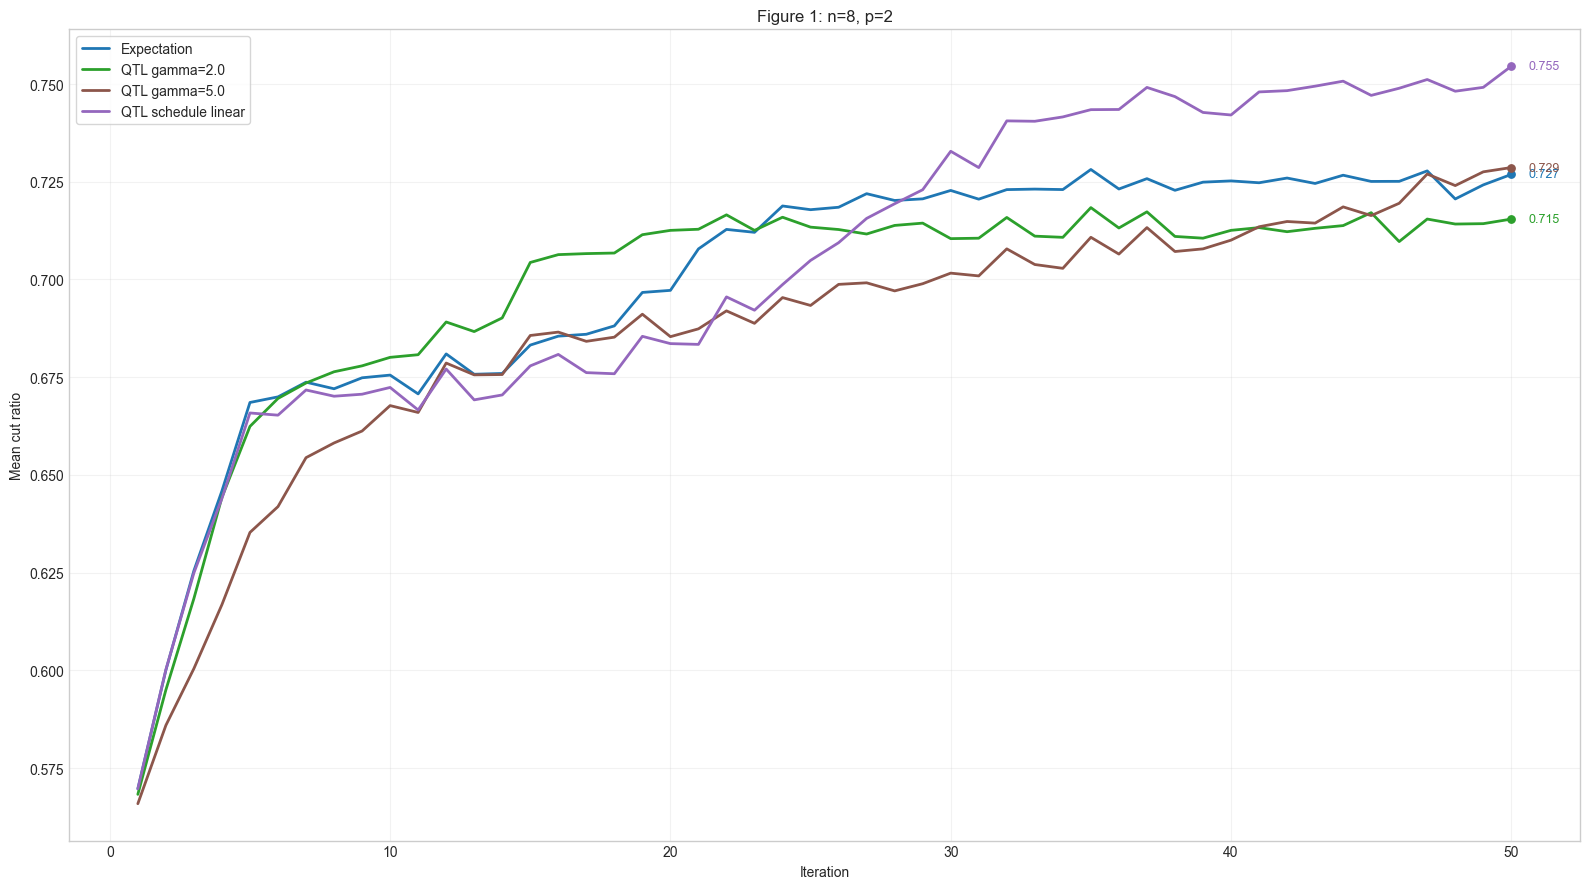

In [34]:
# fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(5 * len(RUN_CONFIG["depths"]), 4), sharey=True)
fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(16, 9), sharey=True)
if len(RUN_CONFIG["depths"]) == 1:
    axes = [axes]
    
for ax, p in zip(axes, RUN_CONFIG["depths"]):
    sub = fig1_df[fig1_df["p"] == p]
    plotted = []
    for name in CURVE_OBJECTIVES:
        agg = plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            "mean_ratio",
            name,
            OBJECTIVE_COLORS[name],
        )
        plotted.append((name, agg))
        ax.text(
            agg["iteration"].iloc[-1] + 0.6,
            agg["mean"].iloc[-1],
            f"{agg['mean'].iloc[-1]:.3f}",
            color=OBJECTIVE_COLORS[name],
            va="center",
            fontsize=9,
        )
    y_min = min(agg["mean"].min() for _, agg in plotted)
    y_max = max(agg["mean"].max() for _, agg in plotted)
    pad = max(0.002, 0.18 * (y_max - y_min + 1e-6))
    ax.set_title(f"Figure 1: n={RUN_CONFIG['curve_n']}, p={p}")
    # ax.set_xticks(list(range(1, len(sub[sub["objective"] == name]) + 1)))
    ax.locator_params(axis='x', integer=True)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean cut ratio")
    # ax.set_ylim(0.45, 1.00)
    ax.grid(alpha=0.25)

axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()

## Gamma sweep aligned with Figure 1 (peak and final mean ratio)

This gamma sweep is adjusted to be more comparable to Figure 1. The sweep below reuses `RUN_CONFIG` directly, focuses on small-to-moderate gamma values, and reports both `peak_mean_ratio` and `final_mean_ratio` along each optimization trajectory. This makes the second figure closer to the question “does a moderate tilt help the optimization path?” while still keeping the final noisy endpoint visible.

For reference, the sweep still computes a `tail_mean_ratio` (the mean over the last 10 iterations), but the plotted metrics are only `peak_mean_ratio` and `final_mean_ratio`.


In [ ]:
def sem(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))


gamma_sweep_config = {**RUN_CONFIG, "shots": 1024}
gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.4, 0.5, 0.56, 0.64, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 1.8, 2.2, 2.6, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0])
tail_window = 10

gamma_rows = []
for graph_family in gamma_sweep_config["graph_families"]:
    for n in gamma_sweep_config["sizes"]:
        for p in gamma_sweep_config["depths"]:
            for seed in gamma_sweep_config["seeds"]:
                for gamma_plot in gamma_plot_values:
                    if abs(gamma_plot) < 1e-12:
                        spec = ObjectiveSpec(
                            name="Expectation",
                            kind="expectation",
                            color="#1f77b4",
                        )
                        gamma_raw = 0.0
                    else:
                        spec = ObjectiveSpec(
                            name=f"QTL gamma={gamma_plot:.2f}",
                            kind="qtl",
                            gamma=float(gamma_plot),
                            color="#2ca02c",
                        )
                        gamma_raw = float(gamma_plot)

                    history, final_summary = run_single_setting(
                        graph_family=graph_family,
                        n=n,
                        p=p,
                        seed=seed,
                        spec=spec,
                        config=gamma_sweep_config,
                        exact=False,
                    )

                    gamma_rows.append(
                        {
                            "graph_family": graph_family,
                            "n": n,
                            "p": p,
                            "seed": seed,
                            "gamma_plot": float(gamma_plot),
                            "gamma_raw": float(gamma_raw),
                            "final_mean_ratio": float(final_summary["final_mean_ratio"]),
                            "tail_mean_ratio": float(history["mean_ratio"].tail(min(tail_window, len(history))).mean()),
                            "peak_mean_ratio": float(history["mean_ratio"].max()),
                            "final_optimal_mass": float(final_summary["final_optimal_mass"]),
                        }
                    )

gamma_df = pd.DataFrame(gamma_rows)
gamma_df.to_csv('fixed_gamma2.csv')
gamma_summary_df = (
    gamma_df.groupby("gamma_plot")
    .agg(
        mean_peak_ratio=("peak_mean_ratio", "mean"),
        sem_peak_ratio=("peak_mean_ratio", sem),
        mean_tail_ratio=("tail_mean_ratio", "mean"),
        sem_tail_ratio=("tail_mean_ratio", sem),
        mean_final_ratio=("final_mean_ratio", "mean"),
        sem_final_ratio=("final_mean_ratio", sem),
        mean_optimal_mass=("final_optimal_mass", "mean"),
    )
    .reset_index()
    .sort_values("gamma_plot")
)

gamma_summary_df.to_csv('fixed_gamma_group.csv')


# output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.png"
# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.pdf"


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
    PyErr_CheckSignals()
^^^^^^^^^^^
KeyboardInterrupt: 


# Less shots required

To Yixian: you can modify yje shots in the following cell. Remember to change the csv file names.

In [31]:
def sem(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))


gamma_sweep_config = {**RUN_CONFIG, "shots": 128}
gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.38, 0.4, 0.5, 0.56, 0.6, 0.64, 0.7, 0.74, 0.8, 0.85, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.35, 1.4, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0])
# 1.8, 2.2, 2.6,
tail_window = 10

gamma_rows = []
for graph_family in gamma_sweep_config["graph_families"]:
    for n in gamma_sweep_config["sizes"]:
        for p in gamma_sweep_config["depths"]:
            for seed in gamma_sweep_config["seeds"]:
                for gamma_plot in gamma_plot_values:
                    if abs(gamma_plot) < 1e-12:
                        spec = ObjectiveSpec(
                            name="Expectation",
                            kind="expectation",
                            color="#1f77b4",
                        )
                        gamma_raw = 0.0
                    else:
                        spec = ObjectiveSpec(
                            name=f"QTL gamma={gamma_plot:.2f}",
                            kind="qtl",
                            gamma=float(gamma_plot),
                            color="#2ca02c",
                        )
                        gamma_raw = float(gamma_plot)

                    history, final_summary = run_single_setting(
                        graph_family=graph_family,
                        n=n,
                        p=p,
                        seed=seed,
                        spec=spec,
                        config=gamma_sweep_config,
                        exact=False,
                    )

                    gamma_rows.append(
                        {
                            "graph_family": graph_family,
                            "n": n,
                            "p": p,
                            "seed": seed,
                            "gamma_plot": float(gamma_plot),
                            "gamma_raw": float(gamma_raw),
                            "final_mean_ratio": float(final_summary["final_mean_ratio"]),
                            "tail_mean_ratio": float(history["mean_ratio"].tail(min(tail_window, len(history))).mean()),
                            "peak_mean_ratio": float(history["mean_ratio"].max()),
                            "final_optimal_mass": float(final_summary["final_optimal_mass"]),
                        }
                    )

gamma_df = pd.DataFrame(gamma_rows)
gamma_df.to_csv('fixed_gamma_shot_128.csv')
gamma_summary_df = (
    gamma_df.groupby("gamma_plot")
    .agg(
        mean_peak_ratio=("peak_mean_ratio", "mean"),
        sem_peak_ratio=("peak_mean_ratio", sem),
        mean_tail_ratio=("tail_mean_ratio", "mean"),
        sem_tail_ratio=("tail_mean_ratio", sem),
        mean_final_ratio=("final_mean_ratio", "mean"),
        sem_final_ratio=("final_mean_ratio", sem),
        mean_optimal_mass=("final_optimal_mass", "mean"),
    )
    .reset_index()
    .sort_values("gamma_plot")
)

gamma_summary_df.to_csv('fixed_gamma_shot_128_group.csv')


# output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.png"
# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.pdf"


In [33]:
def sem(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))


gamma_sweep_config = {**RUN_CONFIG, "shots": 256}
gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.38, 0.4, 0.5, 0.56, 0.6, 0.64, 0.7, 0.74, 0.8, 0.85, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.35, 1.4, 1.5, 1.8, 2.2, 2.6, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0])
tail_window = 10

gamma_rows = []
for graph_family in gamma_sweep_config["graph_families"]:
    for n in gamma_sweep_config["sizes"]:
        for p in gamma_sweep_config["depths"]:
            for seed in gamma_sweep_config["seeds"]:
                for gamma_plot in gamma_plot_values:
                    if abs(gamma_plot) < 1e-12:
                        spec = ObjectiveSpec(
                            name="Expectation",
                            kind="expectation",
                            color="#1f77b4",
                        )
                        gamma_raw = 0.0
                    else:
                        spec = ObjectiveSpec(
                            name=f"QTL gamma={gamma_plot:.2f}",
                            kind="qtl",
                            gamma=float(gamma_plot),
                            color="#2ca02c",
                        )
                        gamma_raw = float(gamma_plot)

                    history, final_summary = run_single_setting(
                        graph_family=graph_family,
                        n=n,
                        p=p,
                        seed=seed,
                        spec=spec,
                        config=gamma_sweep_config,
                        exact=False,
                    )

                    gamma_rows.append(
                        {
                            "graph_family": graph_family,
                            "n": n,
                            "p": p,
                            "seed": seed,
                            "gamma_plot": float(gamma_plot),
                            "gamma_raw": float(gamma_raw),
                            "final_mean_ratio": float(final_summary["final_mean_ratio"]),
                            "tail_mean_ratio": float(history["mean_ratio"].tail(min(tail_window, len(history))).mean()),
                            "peak_mean_ratio": float(history["mean_ratio"].max()),
                            "final_optimal_mass": float(final_summary["final_optimal_mass"]),
                        }
                    )

gamma_df = pd.DataFrame(gamma_rows)
gamma_df.to_csv('fixed_gamma_shot_256.csv')
gamma_summary_df = (
    gamma_df.groupby("gamma_plot")
    .agg(
        mean_peak_ratio=("peak_mean_ratio", "mean"),
        sem_peak_ratio=("peak_mean_ratio", sem),
        mean_tail_ratio=("tail_mean_ratio", "mean"),
        sem_tail_ratio=("tail_mean_ratio", sem),
        mean_final_ratio=("final_mean_ratio", "mean"),
        sem_final_ratio=("final_mean_ratio", sem),
        mean_optimal_mass=("final_optimal_mass", "mean"),
    )
    .reset_index()
    .sort_values("gamma_plot")
)

gamma_summary_df.to_csv('fixed_gamma_shot_256_group.csv')


# output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.png"
# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.pdf"


In [34]:
def sem(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))


gamma_sweep_config = {**RUN_CONFIG, "shots": 512}
gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.38, 0.4, 0.5, 0.56, 0.6, 0.64, 0.7, 0.74, 0.8, 0.85, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.35, 1.4, 1.5, 1.8, 2.2, 2.6, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0])
tail_window = 10

gamma_rows = []
for graph_family in gamma_sweep_config["graph_families"]:
    for n in gamma_sweep_config["sizes"]:
        for p in gamma_sweep_config["depths"]:
            for seed in gamma_sweep_config["seeds"]:
                for gamma_plot in gamma_plot_values:
                    if abs(gamma_plot) < 1e-12:
                        spec = ObjectiveSpec(
                            name="Expectation",
                            kind="expectation",
                            color="#1f77b4",
                        )
                        gamma_raw = 0.0
                    else:
                        spec = ObjectiveSpec(
                            name=f"QTL gamma={gamma_plot:.2f}",
                            kind="qtl",
                            gamma=float(gamma_plot),
                            color="#2ca02c",
                        )
                        gamma_raw = float(gamma_plot)

                    history, final_summary = run_single_setting(
                        graph_family=graph_family,
                        n=n,
                        p=p,
                        seed=seed,
                        spec=spec,
                        config=gamma_sweep_config,
                        exact=False,
                    )

                    gamma_rows.append(
                        {
                            "graph_family": graph_family,
                            "n": n,
                            "p": p,
                            "seed": seed,
                            "gamma_plot": float(gamma_plot),
                            "gamma_raw": float(gamma_raw),
                            "final_mean_ratio": float(final_summary["final_mean_ratio"]),
                            "tail_mean_ratio": float(history["mean_ratio"].tail(min(tail_window, len(history))).mean()),
                            "peak_mean_ratio": float(history["mean_ratio"].max()),
                            "final_optimal_mass": float(final_summary["final_optimal_mass"]),
                        }
                    )

gamma_df = pd.DataFrame(gamma_rows)
gamma_df.to_csv('fixed_gamma_shot_512.csv')
gamma_summary_df = (
    gamma_df.groupby("gamma_plot")
    .agg(
        mean_peak_ratio=("peak_mean_ratio", "mean"),
        sem_peak_ratio=("peak_mean_ratio", sem),
        mean_tail_ratio=("tail_mean_ratio", "mean"),
        sem_tail_ratio=("tail_mean_ratio", sem),
        mean_final_ratio=("final_mean_ratio", "mean"),
        sem_final_ratio=("final_mean_ratio", sem),
        mean_optimal_mass=("final_optimal_mass", "mean"),
    )
    .reset_index()
    .sort_values("gamma_plot")
)

gamma_summary_df.to_csv('fixed_gamma_shot_512_group.csv')


# output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.png"
# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.pdf"


# New Gammas added

C:\Users\fff\AppData\Local\Temp\ipykernel_10996\4203377018.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(float(x_values.min()) - 0.1, float(x_values.max()) + 0.15)


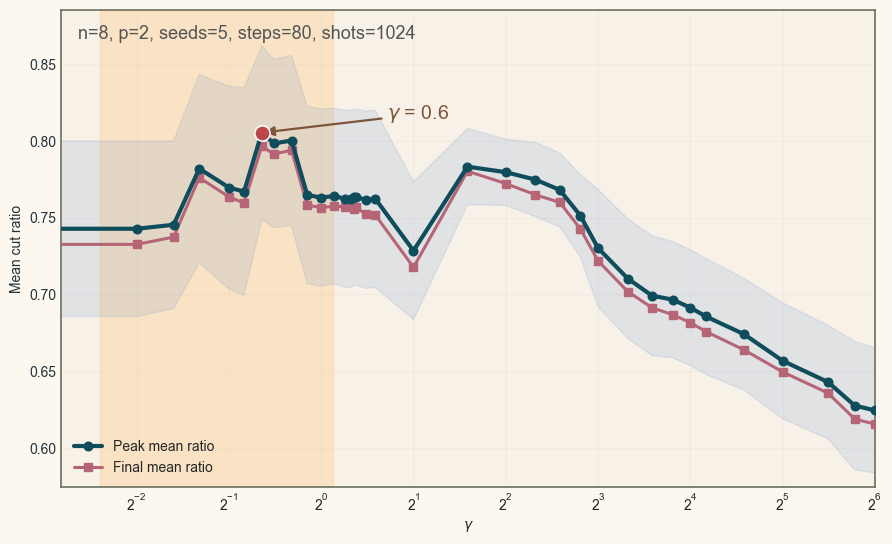

In [14]:
def sem(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))


gamma_sweep_config = {**RUN_CONFIG, "shots": 100000}
gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.38, 0.4, 0.5, 0.56, 0.6, 0.64, 0.7,0.74, 0.8, 0.85, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0, 128, 256, 512, 1024])
tail_window = 10

gamma_rows = []
for graph_family in gamma_sweep_config["graph_families"]:
    for n in gamma_sweep_config["sizes"]:
        for p in gamma_sweep_config["depths"]:
            for seed in gamma_sweep_config["seeds"]:
                for gamma_plot in gamma_plot_values:
                    if abs(gamma_plot) < 1e-12:
                        spec = ObjectiveSpec(
                            name="Expectation",
                            kind="expectation",
                            color="#1f77b4",
                        )
                        gamma_raw = 0.0
                    else:
                        spec = ObjectiveSpec(
                            name=f"QTL gamma={gamma_plot:.2f}",
                            kind="qtl",
                            gamma=float(gamma_plot),
                            color="#2ca02c",
                        )
                        gamma_raw = float(gamma_plot)

                    history, final_summary = run_single_setting(
                        graph_family=graph_family,
                        n=n,
                        p=p,
                        seed=seed,
                        spec=spec,
                        config=gamma_sweep_config,
                        exact=False,
                    )

                    gamma_rows.append(
                        {
                            "graph_family": graph_family,
                            "n": n,
                            "p": p,
                            "seed": seed,
                            "gamma_plot": float(gamma_plot),
                            "gamma_raw": float(gamma_raw),
                            "final_mean_ratio": float(final_summary["final_mean_ratio"]),
                            "tail_mean_ratio": float(history["mean_ratio"].tail(min(tail_window, len(history))).mean()),
                            "peak_mean_ratio": float(history["mean_ratio"].max()),
                            "final_optimal_mass": float(final_summary["final_optimal_mass"]),
                        }
                    )

gamma_df = pd.DataFrame(gamma_rows)
gamma_df.to_csv('fixed_gamma_shot_100000.csv')
gamma_summary_df = (
    gamma_df.groupby("gamma_plot")
    .agg(
        mean_peak_ratio=("peak_mean_ratio", "mean"),
        sem_peak_ratio=("peak_mean_ratio", sem),
        mean_tail_ratio=("tail_mean_ratio", "mean"),
        sem_tail_ratio=("tail_mean_ratio", sem),
        mean_final_ratio=("final_mean_ratio", "mean"),
        sem_final_ratio=("final_mean_ratio", sem),
        mean_optimal_mass=("final_optimal_mass", "mean"),
    )
    .reset_index()
    .sort_values("gamma_plot")
)

gamma_summary_df.to_csv('fixed_gamma_shot_100000_group.csv')


# output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.png"
# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_peak_mean_ratio.pdf"


In [ ]:
import pandas as pd
# New gammas added

# Load a local CSV file
gamma_summary_df = pd.read_csv('fixed_gamma.csv')


In [ ]:
gammas = gamma_summary_df['gamma_plot']
print(gammas)

In [ ]:
gamma_sweep_config = {**RUN_CONFIG, "shots": 1024}
# gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.38, 0.4, 0.5, 0.56, 0.6, 0.64, 0.7,0.74, 0.8, 0.85, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0])

tail_window = 10
best_idx = gamma_summary_df["mean_final_ratio"].idxmax()
best_gamma = float(gamma_summary_df.loc[best_idx, "gamma_plot"])
best_ratio = float(gamma_summary_df.loc[best_idx, "mean_final_ratio"])

x_values = gamma_summary_df["gamma_plot"].to_numpy(dtype=float)
plot_metric = "mean_final_ratio"
plot_sem = "sem_final_ratio"
# point_metric = "peak_mean_ratio"
y_min = max(0.30, float(gamma_summary_df[plot_metric].min()) - 0.05)
y_max = min(0.98, float(gamma_summary_df[plot_metric].max()) + 0.03)

best_region_half_width = 0.45


fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")
ax.axvspan(
    max(float(x_values.min()), best_gamma - best_region_half_width),
    min(float(x_values.max()), best_gamma + best_region_half_width),
    color="#ffbf69",
    alpha=0.28,
    zorder=0,
)
ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"] - gamma_summary_df["sem_final_ratio"],
    gamma_summary_df["mean_final_ratio"] + gamma_summary_df["sem_final_ratio"],
    color="#5f88c9",
    alpha=0.14,
    zorder=1,
)
ax.scatter(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#7f5539",
    s=30,
    alpha=0.14,
    zorder=2,
)
ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.2,
    zorder=4,
    label="Mean Final Ratio",
)
# ax.plot(
#     gamma_summary_df["gamma_plot"],
#     gamma_summary_df["mean_final_ratio"],
#     color="#b56576",
#     linewidth=2.2,
#     marker="s",
#     markersize=5.2,
#     zorder=3,
#     label="Final mean ratio",
# )
ax.scatter([best_gamma], [best_ratio], color="#bc4749", s=120, edgecolor="white", linewidth=1.1, zorder=5)
ax.annotate(
    f"$\\gamma$ = {best_gamma:.1f}",
    xy=(best_gamma, best_ratio),
    xytext=(min(float(x_values.max()) - 0.9, best_gamma + 1.0), min(y_max - 0.005, best_ratio + 0.012)),
    fontsize=14,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.6},
)

# ax.text(0.11, 1.02, "Weak tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")
# ax.text(0.50, 1.02, "Best region", transform=ax.transAxes, fontsize=21, ha="center", color="#7f5539")
# ax.text(0.88, 1.02, "Strong tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")

# ax.set_title("QTL-QAOA gamma sweep", pad=18, color="#22333b")
ax.text(
    0.02,
    0.94,
    f"n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=13,
    color="#555555",
)
ax.set_xlabel("$\\gamma$")
ax.set_ylabel("Mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(float(x_values.min()) - 0.1, float(x_values.max()) + 0.15)
ax.set_ylim(y_min, y_max+0.05)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(output_png, bbox_inches="tight", dpi=240)
# fig.savefig(output_pdf, bbox_inches="tight")
# plt.show()

# print(f"Saved {output_png}")
# print(f"Saved {output_pdf}")
# display(gamma_summary_df.round(4))


In [ ]:
gamma_sweep_config = {**RUN_CONFIG, "shots": 1024}
# gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.38, 0.4, 0.5, 0.56, 0.6, 0.64, 0.7,0.74, 0.8, 0.85, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0])

tail_window = 10
best_idx = gamma_summary_df["mean_final_ratio"].idxmax()
best_gamma = float(gamma_summary_df.loc[best_idx, "gamma_plot"])
best_ratio = float(gamma_summary_df.loc[best_idx, "mean_final_ratio"])

x_values = gamma_summary_df["gamma_plot"].to_numpy(dtype=float)
plot_metric = "mean_final_ratio"
plot_sem = "sem_final_ratio"
# point_metric = "peak_mean_ratio"
y_min = max(0.30, float(gamma_summary_df[plot_metric].min()) - 0.05)
y_max = min(0.98, float(gamma_summary_df[plot_metric].max()) + 0.03)

best_region_half_width = 0.45


fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")
ax.axvspan(
    max(float(x_values.min()), best_gamma - best_region_half_width),
    min(float(x_values.max()), best_gamma + best_region_half_width),
    color="#ffbf69",
    alpha=0.28,
    zorder=0,
)
ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"] - gamma_summary_df["sem_final_ratio"],
    gamma_summary_df["mean_final_ratio"] + gamma_summary_df["sem_final_ratio"],
    color="#5f88c9",
    alpha=0.14,
    zorder=1,
)
ax.scatter(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#7f5539",
    s=30,
    alpha=0.14,
    zorder=2,
)
ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.2,
    zorder=4,
    label="Mean Final Ratio",
)
# ax.plot(
#     gamma_summary_df["gamma_plot"],
#     gamma_summary_df["mean_final_ratio"],
#     color="#b56576",
#     linewidth=2.2,
#     marker="s",
#     markersize=5.2,
#     zorder=3,
#     label="Final mean ratio",
# )
ax.scatter([best_gamma], [best_ratio], color="#bc4749", s=120, edgecolor="white", linewidth=1.1, zorder=5)
ax.annotate(
    f"$\\gamma$ = {best_gamma:.1f}",
    xy=(best_gamma, best_ratio),
    xytext=(min(float(x_values.max()) - 0.9, best_gamma + 1.0), min(y_max - 0.005, best_ratio + 0.012)),
    fontsize=14,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.6},
)

# ax.text(0.11, 1.02, "Weak tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")
# ax.text(0.50, 1.02, "Best region", transform=ax.transAxes, fontsize=21, ha="center", color="#7f5539")
# ax.text(0.88, 1.02, "Strong tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")

# ax.set_title("QTL-QAOA gamma sweep", pad=18, color="#22333b")
ax.text(
    0.02,
    0.94,
    f"n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=13,
    color="#555555",
)
ax.set_xlabel("$\\gamma$")
ax.set_xscale('log', base=10)
# ax.set_xscale('log', base=2)

ax.set_ylabel("Mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(float(x_values.min()) - 0.1, float(x_values.max()) + 0.15)
ax.set_ylim(y_min, y_max+0.05)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(output_png, bbox_inches="tight", dpi=240)
# fig.savefig(output_pdf, bbox_inches="tight")
# plt.show()

# print(f"Saved {output_png}")
# print(f"Saved {output_pdf}")
# display(gamma_summary_df.round(4))


# Increase the scale of gamma a bit for various shots

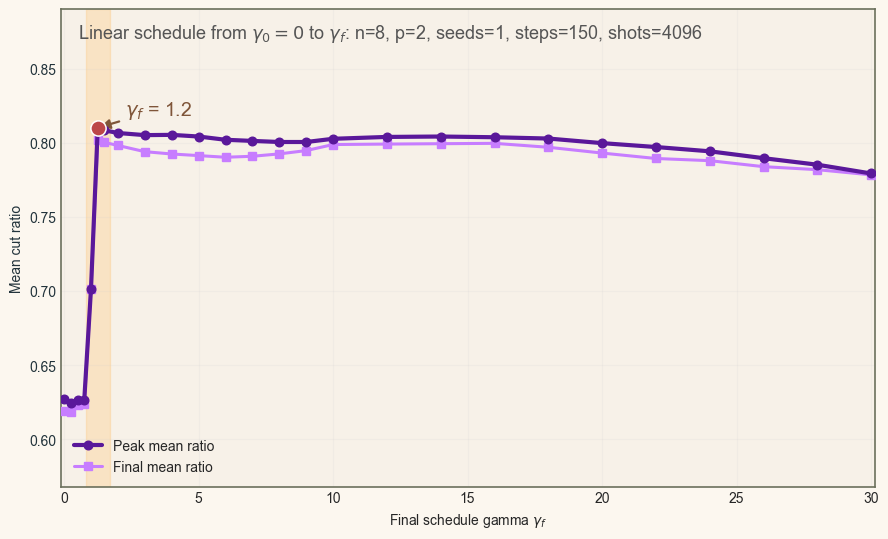

Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_linear_schedule_gamma_sweep.png
Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_linear_schedule_gamma_sweep.pdf


,gamma_plot,mean_peak_ratio,sem_peak_ratio,mean_tail_ratio,sem_tail_ratio,mean_final_ratio,sem_final_ratio,mean_optimal_mass
0,0.00,0.6273,0.0,0.6176,0.0,0.6192,0.0,0.0266
1,0.25,0.6244,0.0,0.6197,0.0,0.6181,0.0,0.0293
2,0.50,0.6264,0.0,0.6201,0.0,0.6229,0.0,0.0342
3,0.75,0.6268,0.0,0.6237,0.0,0.6236,0.0,0.0432
4,1.00,0.7017,0.0,0.6792,0.0,0.7017,0.0,0.1250
5,1.25,0.8102,0.0,0.8030,0.0,0.8019,0.0,0.2219
6,1.50,0.8085,0.0,0.8024,0.0,0.8003,0.0,0.2224
7,2.00,0.8066,0.0,0.7991,0.0,0.7982,0.0,0.2236
8,3.00,0.8052,0.0,0.7950,0.0,0.7940,0.0,0.2241
9,4.00,0.8054,0.0,0.7931,0.0,0.7925,0.0,0.2258


In [ ]:
# Load a local CSV file
gamma_summary_df = pd.read_csv('fixed_gamma.csv')

# View the first few rows
print(gamma_summary_df.head())

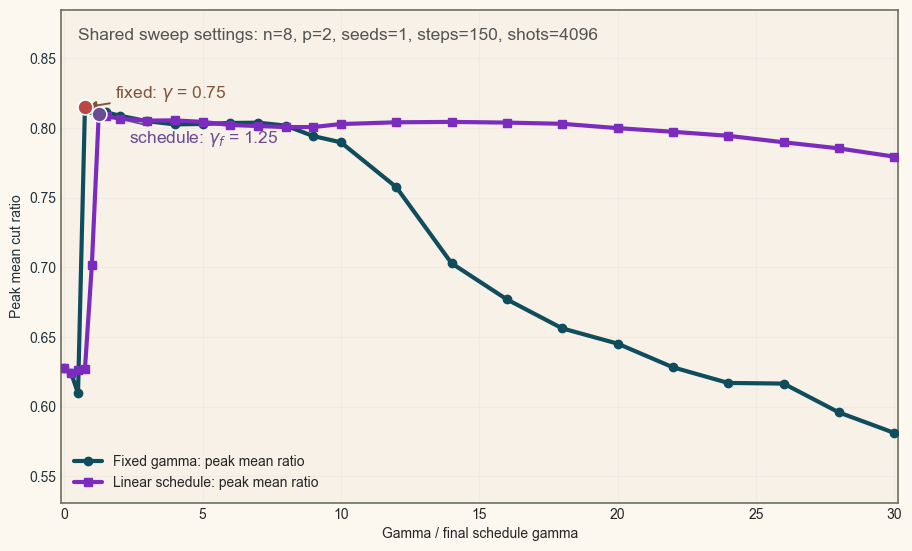

Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.png
Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.pdf


In [26]:
gamma_sweep_config = {**RUN_CONFIG, "shots": 1024}
gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.4, 0.5, 0.56, 0.64, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0])
tail_window = 10
best_idx = gamma_summary_df["mean_peak_ratio"].idxmax()
best_gamma = float(gamma_summary_df.loc[best_idx, "gamma_plot"])
best_ratio = float(gamma_summary_df.loc[best_idx, "mean_peak_ratio"])

x_values = gamma_summary_df["gamma_plot"].to_numpy(dtype=float)
plot_metric = "mean_peak_ratio"
plot_sem = "sem_peak_ratio"
# point_metric = "peak_mean_ratio"
y_min = max(0.30, float(gamma_summary_df[plot_metric].min()) - 0.05)
y_max = min(0.98, float(gamma_summary_df[plot_metric].max()) + 0.03)

best_region_half_width = 0.45


fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")
ax.axvspan(
    max(float(x_values.min()), best_gamma - best_region_half_width),
    min(float(x_values.max()), best_gamma + best_region_half_width),
    color="#ffbf69",
    alpha=0.28,
    zorder=0,
)
ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"] - gamma_summary_df["sem_peak_ratio"],
    gamma_summary_df["mean_peak_ratio"] + gamma_summary_df["sem_peak_ratio"],
    color="#5f88c9",
    alpha=0.14,
    zorder=1,
)
ax.scatter(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"],
    color="#7f5539",
    s=30,
    alpha=0.14,
    zorder=2,
)
ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.2,
    zorder=4,
    label="Peak mean ratio",
)
ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#b56576",
    linewidth=2.2,
    marker="s",
    markersize=5.2,
    zorder=3,
    label="Final mean ratio",
)
ax.scatter([best_gamma], [best_ratio], color="#bc4749", s=120, edgecolor="white", linewidth=1.1, zorder=5)
ax.annotate(
    f"$\\gamma$ = {best_gamma:.1f}",
    xy=(best_gamma, best_ratio),
    xytext=(min(float(x_values.max()) - 0.9, best_gamma + 1.0), min(y_max - 0.005, best_ratio + 0.012)),
    fontsize=14,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.6},
)

# ax.text(0.11, 1.02, "Weak tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")
# ax.text(0.50, 1.02, "Best region", transform=ax.transAxes, fontsize=21, ha="center", color="#7f5539")
# ax.text(0.88, 1.02, "Strong tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")

# ax.set_title("QTL-QAOA gamma sweep", pad=18, color="#22333b")
ax.text(
    0.02,
    0.94,
    f"n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=13,
    color="#555555",
)
ax.set_xlabel("$\\gamma$")
ax.set_ylabel("Mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(float(x_values.min()) - 0.1, float(x_values.max()) + 0.15)
ax.set_ylim(y_min, y_max+0.05)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(output_png, bbox_inches="tight", dpi=240)
# fig.savefig(output_pdf, bbox_inches="tight")
# plt.show()

# print(f"Saved {output_png}")
# print(f"Saved {output_pdf}")
# display(gamma_summary_df.round(4))


In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")
ax.axvspan(
    max(float(x_values.min()), best_gamma - best_region_half_width),
    min(float(x_values.max()), best_gamma + best_region_half_width),
    color="#ffbf69",
    alpha=0.28,
    zorder=0,
)
ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"] - gamma_summary_df["sem_peak_ratio"],
    gamma_summary_df["mean_peak_ratio"] + gamma_summary_df["sem_peak_ratio"],
    color="#5f88c9",
    alpha=0.14,
    zorder=1,
)
ax.scatter(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"],
    color="#7f5539",
    s=30,
    alpha=0.14,
    zorder=2,
)
ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.2,
    zorder=4,
    label="Peak mean ratio",
)
ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#b56576",
    linewidth=2.2,
    marker="s",
    markersize=5.2,
    zorder=3,
    label="Final mean ratio",
)
ax.scatter([best_gamma], [best_ratio], color="#bc4749", s=120, edgecolor="white", linewidth=1.1, zorder=5)
ax.annotate(
    f"$\\gamma$ = {best_gamma:.1f}",
    xy=(best_gamma, best_ratio),
    xytext=(min(float(x_values.max()) - 0.9, best_gamma + 1.0), min(y_max - 0.005, best_ratio + 0.012)),
    fontsize=14,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.6},
)

# ax.text(0.11, 1.02, "Weak tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")
# ax.text(0.50, 1.02, "Best region", transform=ax.transAxes, fontsize=21, ha="center", color="#7f5539")
# ax.text(0.88, 1.02, "Strong tilt", transform=ax.transAxes, fontsize=21, ha="center", color="#5c5346")

# ax.set_title("QTL-QAOA gamma sweep", pad=18, color="#22333b")
ax.text(
    0.02,
    0.94,
    f"n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=13,
    color="#555555",
)
ax.set_xlabel("$\\gamma$")
ax.set_ylabel("Mean cut ratio", color="#22333b")
ax.set_xscale('log', base=2)
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(float(x_values.min()) - 0.1, float(x_values.max()) + 0.15)
ax.set_ylim(y_min, y_max+0.05)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(output_png, bbox_inches="tight", dpi=240)
# fig.savefig(output_pdf, bbox_inches="tight")
# plt.show()

# print(f"Saved {output_png}")
# print(f"Saved {output_pdf}")
# display(gamma_summary_df.round(4))


# Plot the figure of all shots

## Linear-schedule gamma sweep aligned with Part 2

This third part keeps the fixed-gamma sweep above unchanged and adds a `linear` schedule sweep. For each sweep point, the schedule starts from `gamma_start = 0` and ends at `gamma_end = gamma_plot`, while the optimizer, shots, step budget, graph family, size, depth, and seeds are all reused directly from the fixed-gamma sweep in Part 2.

The plot below summarizes the schedule strategy using the same two metrics as Part 2: `peak_mean_ratio` and `final_mean_ratio`.


C:\Users\fff\AppData\Local\Temp\ipykernel_4008\3529244570.py:109: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(float(gamma_plot_values.min()) - 0.1, float(gamma_plot_values.max()) + 0.15)


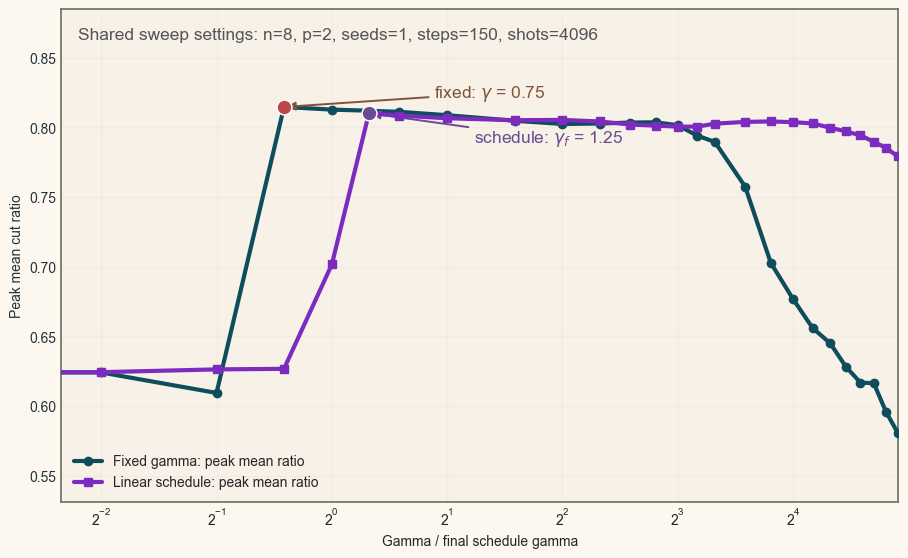

In [ ]:
gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.4, 0.5, 0.56, 0.64, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 1.8, 2.3, 2.6, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0])

schedule_gamma_rows = []
for graph_family in gamma_sweep_config["graph_families"]:
    for n in gamma_sweep_config["sizes"]:
        for p in gamma_sweep_config["depths"]:
            for seed in gamma_sweep_config["seeds"]:
                for gamma_plot in gamma_plot_values:
                    spec = ObjectiveSpec(
                        name=f"QTL linear schedule to {gamma_plot:.2f}",
                        kind="qtl_schedule",
                        gamma_start=0.0,
                        gamma_end=float(gamma_plot),
                        schedule="linear",
                        color="#9467bd",
                    )

                    history, final_summary = run_single_setting(
                        graph_family=graph_family,
                        n=n,
                        p=p,
                        seed=seed,
                        spec=spec,
                        config=gamma_sweep_config,
                        exact=False,
                    )

                    schedule_gamma_rows.append(
                        {
                            "graph_family": graph_family,
                            "n": n,
                            "p": p,
                            "seed": seed,
                            "gamma_plot": float(gamma_plot),
                            "gamma_start": 0.0,
                            "gamma_end": float(gamma_plot),
                            "final_mean_ratio": float(final_summary["final_mean_ratio"]),
                            "tail_mean_ratio": float(history["mean_ratio"].tail(min(tail_window, len(history))).mean()),
                            "peak_mean_ratio": float(history["mean_ratio"].max()),
                            "final_optimal_mass": float(final_summary["final_optimal_mass"]),
                        }
                    )

schedule_gamma_df = pd.DataFrame(schedule_gamma_rows)
schedule_gamma_summary_df = (
    schedule_gamma_df.groupby("gamma_plot")
    .agg(
        mean_peak_ratio=("peak_mean_ratio", "mean"),
        sem_peak_ratio=("peak_mean_ratio", sem),
        mean_tail_ratio=("tail_mean_ratio", "mean"),
        sem_tail_ratio=("tail_mean_ratio", sem),
        mean_final_ratio=("final_mean_ratio", "mean"),
        sem_final_ratio=("final_mean_ratio", sem),
        mean_optimal_mass=("final_optimal_mass", "mean"),
    )
    .reset_index()
    .sort_values("gamma_plot")
)

schedule_gamma_df.to_csv('schedule_gamma_df_2.csv')
schedule_gamma_summary_df.to_csv('schedule_gamma_df_group_2.csv')

schedule_best_idx = schedule_gamma_summary_df["mean_peak_ratio"].idxmax()
schedule_best_gamma = float(schedule_gamma_summary_df.loc[schedule_best_idx, "gamma_plot"])
schedule_best_ratio = float(schedule_gamma_summary_df.loc[schedule_best_idx, "mean_peak_ratio"])

schedule_x_values = schedule_gamma_summary_df["gamma_plot"].to_numpy(dtype=float)
schedule_y_min = max(0.30, float(schedule_gamma_summary_df["mean_final_ratio"].min()) - 0.05)
schedule_y_max = min(0.98, float(schedule_gamma_summary_df["mean_peak_ratio"].max()) + 0.03)

schedule_best_region_half_width = 0.45
schedule_output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_linear_schedule_gamma_sweep.png"
schedule_output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_linear_schedule_gamma_sweep.pdf"


In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")
ax.axvspan(
    max(float(schedule_x_values.min()), schedule_best_gamma - schedule_best_region_half_width),
    min(float(schedule_x_values.max()), schedule_best_gamma + schedule_best_region_half_width),
    color="#ffbf69",
    alpha=0.28,
    zorder=0,
)
ax.fill_between(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_peak_ratio"] - schedule_gamma_summary_df["sem_peak_ratio"],
    schedule_gamma_summary_df["mean_peak_ratio"] + schedule_gamma_summary_df["sem_peak_ratio"],
    color="#8e9aaf",
    alpha=0.16,
    zorder=1,
)
ax.scatter(
    schedule_gamma_df["gamma_plot"],
    schedule_gamma_df["peak_mean_ratio"],
    color="#7f5539",
    s=30,
    alpha=0.14,
    zorder=2,
)
ax.plot(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_peak_ratio"],
    color="#5a189a",
    linewidth=3.0,
    marker="o",
    markersize=6.2,
    zorder=4,
    label="Peak mean ratio",
)
ax.plot(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"],
    color="#c77dff",
    linewidth=2.2,
    marker="s",
    markersize=5.2,
    zorder=3,
    label="Final mean ratio",
)
ax.scatter([schedule_best_gamma], [schedule_best_ratio], color="#bc4749", s=120, edgecolor="white", linewidth=1.1, zorder=5)
ax.annotate(
    f"$\\gamma_f$ = {schedule_best_gamma:.1f}",
    xy=(schedule_best_gamma, schedule_best_ratio),
    xytext=(min(float(schedule_x_values.max()) - 0.9, schedule_best_gamma + 1.0), min(schedule_y_max - 0.005, schedule_best_ratio + 0.012)),
    fontsize=14,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.6},
)
ax.text(
    0.02,
    0.94,
    f"Linear schedule from $\\gamma_0=0$ to $\\gamma_f$: n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=13,
    color="#555555",
)
ax.set_xlabel("Final schedule gamma $\\gamma_f$")
ax.set_ylabel("Mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(float(schedule_x_values.min()) - 0.1, float(schedule_x_values.max()) + 0.15)
ax.set_ylim(schedule_y_min, schedule_y_max + 0.05)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

fig.savefig(schedule_output_png, bbox_inches="tight", dpi=240)
fig.savefig(schedule_output_pdf, bbox_inches="tight")
plt.show()

print(f"Saved {schedule_output_png}")
print(f"Saved {schedule_output_pdf}")
display(schedule_gamma_summary_df.round(4))


## Fixed-gamma vs linear-schedule comparison

This fourth part overlays the `fixed gamma` sweep and the `linear schedule` sweep on a single figure, using only `peak_mean_ratio`. The fixed-gamma curve comes from Part 2, and the schedule curve comes from Part 3, so this comparison does not rerun anything; it only visualizes the two summaries together.


In [ ]:
# compare_output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.png"
# compare_output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.pdf"

fixed_best_idx = gamma_summary_df["mean_peak_ratio"].idxmax()
fixed_best_gamma = float(gamma_summary_df.loc[fixed_best_idx, "gamma_plot"])
fixed_best_ratio = float(gamma_summary_df.loc[fixed_best_idx, "mean_peak_ratio"])

schedule_best_idx = schedule_gamma_summary_df["mean_peak_ratio"].idxmax()
schedule_best_gamma = float(schedule_gamma_summary_df.loc[schedule_best_idx, "gamma_plot"])
schedule_best_ratio = float(schedule_gamma_summary_df.loc[schedule_best_idx, "mean_peak_ratio"])

compare_y_min = max(
    0.30,
    min(
        float(gamma_summary_df["mean_peak_ratio"].min()),
        float(schedule_gamma_summary_df["mean_peak_ratio"].min()),
    ) - 0.05,
)
compare_y_max = min(
    0.98,
    max(
        float(gamma_summary_df["mean_peak_ratio"].max()),
        float(schedule_gamma_summary_df["mean_peak_ratio"].max()),
    ) + 0.03,
)

fig, ax = plt.subplots(figsize=(10.8, 6.4))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")

ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"] - gamma_summary_df["sem_peak_ratio"],
    gamma_summary_df["mean_peak_ratio"] + gamma_summary_df["sem_peak_ratio"],
    color="#4C78A8",
    alpha=0.14,
    zorder=1,
)
ax.fill_between(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_peak_ratio"] - schedule_gamma_summary_df["sem_peak_ratio"],
    schedule_gamma_summary_df["mean_peak_ratio"] + schedule_gamma_summary_df["sem_peak_ratio"],
    color="#9C6ADE",
    alpha=0.12,
    zorder=1,
)

ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_peak_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.0,
    zorder=3,
    label="Fixed gamma: peak mean ratio",
)
ax.plot(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_peak_ratio"],
    color="#7b2cbf",
    linewidth=3.0,
    marker="s",
    markersize=5.6,
    zorder=4,
    label="Linear schedule: peak mean ratio",
)

ax.scatter([fixed_best_gamma], [fixed_best_ratio], color="#bc4749", s=115, edgecolor="white", linewidth=1.1, zorder=5)
ax.scatter([schedule_best_gamma], [schedule_best_ratio], color="#6a4c93", s=115, edgecolor="white", linewidth=1.1, zorder=5)

ax.annotate(
    f"fixed: $\\gamma$ = {fixed_best_gamma:.2f}",
    xy=(fixed_best_gamma, fixed_best_ratio),
    xytext=(fixed_best_gamma + 1.1, min(compare_y_max - 0.01, fixed_best_ratio + 0.010)),
    fontsize=12.5,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.4},
)
ax.annotate(
    f"schedule: $\\gamma_f$ = {schedule_best_gamma:.2f}",
    xy=(schedule_best_gamma, schedule_best_ratio),
    xytext=(schedule_best_gamma + 1.1, max(compare_y_min + 0.03, schedule_best_ratio - 0.018)),
    fontsize=12.5,
    color="#6a4c93",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#6a4c93", "lw": 1.4},
)

ax.text(
    0.02,
    0.94,
    f"Shared sweep settings: n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=12.5,
    color="#555555",
)
ax.set_xlabel("Gamma / final schedule gamma")
ax.set_ylabel("Peak mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(float(gamma_plot_values.min()) - 0.1, float(gamma_plot_values.max()) + 0.15)
ax.set_ylim(compare_y_min, compare_y_max + 0.04)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

fig.savefig(compare_output_png, bbox_inches="tight", dpi=240)
fig.savefig(compare_output_pdf, bbox_inches="tight")
plt.show()

print(f"Saved {compare_output_png}")
print(f"Saved {compare_output_pdf}")


In [15]:
import pandas as pd
# New gammas added

# Load a local CSV file
gamma_summary_df = pd.read_csv('fixed_gamma_fewer_points.csv')
schedule_gamma_summary_df = pd.read_csv('schedule_gamma_df_group_2_fewer_points.csv')


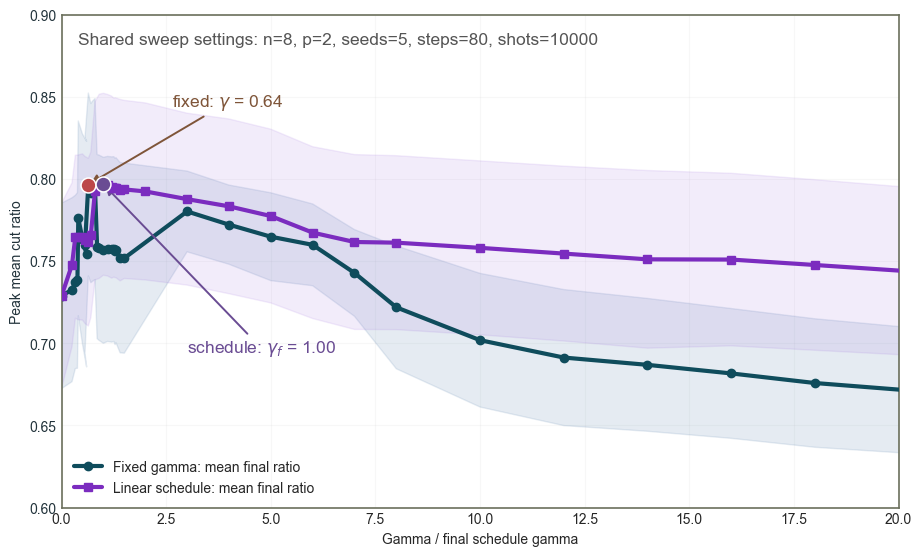

In [21]:
# compare_output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.png"
# compare_output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.pdf"

fixed_best_idx = gamma_summary_df["mean_final_ratio"].idxmax()
fixed_best_gamma = float(gamma_summary_df.loc[fixed_best_idx, "gamma_plot"])
fixed_best_ratio = float(gamma_summary_df.loc[fixed_best_idx, "mean_final_ratio"])

schedule_best_idx = schedule_gamma_summary_df["mean_final_ratio"].idxmax()
schedule_best_gamma = float(schedule_gamma_summary_df.loc[schedule_best_idx, "gamma_plot"])
schedule_best_ratio = float(schedule_gamma_summary_df.loc[schedule_best_idx, "mean_final_ratio"])

compare_y_min = max(
    0.30,
    min(
        float(gamma_summary_df["mean_final_ratio"].min()),
        float(schedule_gamma_summary_df["mean_final_ratio"].min()),
    ) - 0.05,
)
compare_y_max = min(
    0.98,
    max(
        float(gamma_summary_df["mean_final_ratio"].max()),
        float(schedule_gamma_summary_df["mean_final_ratio"].max()),
    ) + 0.03,
)

fig, ax = plt.subplots(figsize=(10.8, 6.4))
# fig.patch.set_facecolor("#fcf7ef")
# ax.set_facecolor("#f7f1e8")

ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"] - gamma_summary_df["sem_final_ratio"],
    gamma_summary_df["mean_final_ratio"] + gamma_summary_df["sem_final_ratio"],
    color="#4C78A8",
    alpha=0.14,
    zorder=1,
)
ax.fill_between(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"] - schedule_gamma_summary_df["sem_final_ratio"],
    schedule_gamma_summary_df["mean_final_ratio"] + schedule_gamma_summary_df["sem_final_ratio"],
    color="#9C6ADE",
    alpha=0.12,
    zorder=1,
)

ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.0,
    zorder=3,
    label="Fixed gamma: mean final ratio",
)
ax.plot(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"],
    color="#7b2cbf",
    linewidth=3.0,
    marker="s",
    markersize=5.6,
    zorder=4,
    label="Linear schedule: mean final ratio",
)

# ax.scatter(
#     gamma_summary_df["gamma_plot"],
#     gamma_summary_df["mean_final_ratio"],
#     color="#0f4c5c",
#     # linewidth=3.0,
#     marker="o",
#     # markersize=6.0,
#     # zorder=3,
#     label="Fixed gamma: mean final ratio",
# )
# ax.scatter(
#     schedule_gamma_summary_df["gamma_plot"],
#     schedule_gamma_summary_df["mean_final_ratio"],
#     color="#7b2cbf",
#     # linewidth=3.0,
#     marker="s",
#     # markersize=5.6,
#     # zorder=4,
#     label="Linear schedule: mean final ratio",
# )

ax.scatter([fixed_best_gamma], [fixed_best_ratio], color="#bc4749", s=115, edgecolor="white", linewidth=1.1, zorder=5)
ax.scatter([schedule_best_gamma], [schedule_best_ratio], color="#6a4c93", s=115, edgecolor="white", linewidth=1.1, zorder=5)

ax.annotate(
    f"fixed: $\\gamma$ = {fixed_best_gamma:.2f}",
    xy=(fixed_best_gamma, fixed_best_ratio),
    xytext=(fixed_best_gamma + 2, fixed_best_ratio + 0.05),
    fontsize=12.5,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.4},
)
ax.annotate(
    f"schedule: $\\gamma_f$ = {schedule_best_gamma:.2f}",
    xy=(schedule_best_gamma, schedule_best_ratio),
    xytext=(schedule_best_gamma + 2, max(compare_y_min + 0.03, schedule_best_ratio - 0.1)),
    fontsize=12.5,
    color="#6a4c93",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#6a4c93", "lw": 1.4},
)

ax.text(
    0.02,
    0.94,
    f"Shared sweep settings: n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=12.5,
    color="#555555",
)
ax.set_xlabel("Gamma / final schedule gamma")
ax.set_ylabel("Peak mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(0, 20)
ax.set_ylim(0.6, 0.9)

# ax.set_ylim(compare_y_min, compare_y_max + 0.04)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(compare_output_png, bbox_inches="tight", dpi=240)
# fig.savefig(compare_output_pdf, bbox_inches="tight")
plt.show()


# print(f"Saved {compare_output_png}")
# print(f"Saved {compare_output_pdf}")


In [ ]:
# compare_output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.png"
# compare_output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.pdf"

fixed_best_idx = gamma_summary_df["mean_final_ratio"].idxmax()
fixed_best_gamma = float(gamma_summary_df.loc[fixed_best_idx, "gamma_plot"])
fixed_best_ratio = float(gamma_summary_df.loc[fixed_best_idx, "mean_final_ratio"])

schedule_best_idx = schedule_gamma_summary_df["mean_final_ratio"].idxmax()
schedule_best_gamma = float(schedule_gamma_summary_df.loc[schedule_best_idx, "gamma_plot"])
schedule_best_ratio = float(schedule_gamma_summary_df.loc[schedule_best_idx, "mean_final_ratio"])

compare_y_min = max(
    0.30,
    min(
        float(gamma_summary_df["mean_final_ratio"].min()),
        float(schedule_gamma_summary_df["mean_final_ratio"].min()),
    ) - 0.05,
)
compare_y_max = min(
    0.98,
    max(
        float(gamma_summary_df["mean_final_ratio"].max()),
        float(schedule_gamma_summary_df["mean_final_ratio"].max()),
    ) + 0.03,
)

fig, ax = plt.subplots(figsize=(10.8, 6.4))
# fig.patch.set_facecolor("#fcf7ef")
# ax.set_facecolor("#f7f1e8")

ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"] - gamma_summary_df["sem_final_ratio"],
    gamma_summary_df["mean_final_ratio"] + gamma_summary_df["sem_final_ratio"],
    color="#4C78A8",
    alpha=0.14,
    zorder=1,
)
ax.fill_between(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"] - schedule_gamma_summary_df["sem_final_ratio"],
    schedule_gamma_summary_df["mean_final_ratio"] + schedule_gamma_summary_df["sem_final_ratio"],
    color="#9C6ADE",
    alpha=0.12,
    zorder=1,
)

ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.0,
    zorder=3,
    label="Fixed gamma: mean final ratio",
)
ax.plot(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"],
    color="#7b2cbf",
    linewidth=3.0,
    marker="s",
    markersize=5.6,
    zorder=4,
    label="Linear schedule: mean final ratio",
)

ax.scatter([fixed_best_gamma], [fixed_best_ratio], color="#bc4749", s=115, edgecolor="white", linewidth=1.1, zorder=5)
ax.scatter([schedule_best_gamma], [schedule_best_ratio], color="#6a4c93", s=115, edgecolor="white", linewidth=1.1, zorder=5)

ax.annotate(
    f"fixed: $\\gamma$ = {fixed_best_gamma:.2f}",
    xy=(fixed_best_gamma, fixed_best_ratio),
    xytext=(fixed_best_gamma + 2, fixed_best_ratio + 0.05),
    fontsize=12.5,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.4},
)
ax.annotate(
    f"schedule: $\\gamma_f$ = {schedule_best_gamma:.2f}",
    xy=(schedule_best_gamma, schedule_best_ratio),
    xytext=(schedule_best_gamma + 2, max(compare_y_min + 0.03, schedule_best_ratio - 0.1)),
    fontsize=12.5,
    color="#6a4c93",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#6a4c93", "lw": 1.4},
)

ax.text(
    0.02,
    0.94,
    f"Shared sweep settings: n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=12.5,
    color="#555555",
)
ax.set_xlabel("Gamma / final schedule gamma")
ax.set_xscale('log', base=2)
ax.set_ylabel("Peak mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(0, 70)
# ax.set_ylim(compare_y_min, compare_y_max + 0.04)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(compare_output_png, bbox_inches="tight", dpi=240)
# fig.savefig(compare_output_pdf, bbox_inches="tight")
plt.show()

# print(f"Saved {compare_output_png}")
# print(f"Saved {compare_output_pdf}")


# PLOT; New data and more shots for ascending

In [8]:
import pandas as pd
# New gammas added


# Load a local CSV file
gamma_summary_df = pd.read_csv('fixed_gamma.csv')
schedule_gamma_summary_df = pd.read_csv('schedule_gamma_df_more_data_and_more_shots_group.csv')


Linear scale

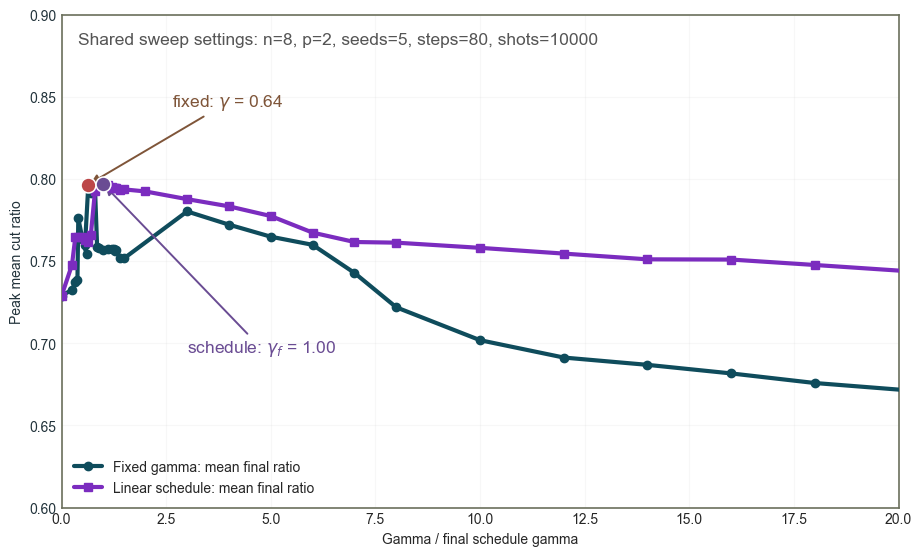

In [20]:
# compare_output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.png"
# compare_output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.pdf"

gamma_sweep_config = {**RUN_CONFIG, "shots": 10000}
# gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.4, 0.5, 0.56, 0.64, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0])
# tail_window = 10

fixed_best_idx = gamma_summary_df["mean_final_ratio"].idxmax()
fixed_best_gamma = float(gamma_summary_df.loc[fixed_best_idx, "gamma_plot"])
fixed_best_ratio = float(gamma_summary_df.loc[fixed_best_idx, "mean_final_ratio"])

schedule_best_idx = schedule_gamma_summary_df["mean_final_ratio"].idxmax()
schedule_best_gamma = float(schedule_gamma_summary_df.loc[schedule_best_idx, "gamma_plot"])
schedule_best_ratio = float(schedule_gamma_summary_df.loc[schedule_best_idx, "mean_final_ratio"])

compare_y_min = max(
    0.30,
    min(
        float(gamma_summary_df["mean_final_ratio"].min()),
        float(schedule_gamma_summary_df["mean_final_ratio"].min()),
    ) - 0.05,
)
compare_y_max = min(
    0.98,
    max(
        float(gamma_summary_df["mean_final_ratio"].max()),
        float(schedule_gamma_summary_df["mean_final_ratio"].max()),
    ) + 0.03,
)

fig, ax = plt.subplots(figsize=(10.8, 6.4))
# fig.patch.set_facecolor("#fcf7ef")
# ax.set_facecolor("#f7f1e8")

# ax.scatter(
#     gamma_summary_df["gamma_plot"],
#     gamma_summary_df["mean_final_ratio"],
#     color="#0f4c5c",
#     # linewidth=3.0,
#     marker="o",
#     # markersize=6.0,
#     # zorder=3,
#     label="Fixed gamma: mean final ratio",
# )
# ax.scatter(
#     schedule_gamma_summary_df["gamma_plot"],
#     schedule_gamma_summary_df["mean_final_ratio"],
#     color="#7b2cbf",
#     # linewidth=3.0,
#     marker="s",
#     # markersize=5.6,
#     # zorder=4,
#     label="Linear schedule: mean final ratio",
# )


# ax.fill_between(
#     gamma_summary_df["gamma_plot"],
#     gamma_summary_df["mean_final_ratio"] - gamma_summary_df["sem_final_ratio"],
#     gamma_summary_df["mean_final_ratio"] + gamma_summary_df["sem_final_ratio"],
#     color="#4C78A8",
#     alpha=0.14,
#     zorder=1,
# )
# ax.fill_between(
#     schedule_gamma_summary_df["gamma_plot"],
#     schedule_gamma_summary_df["mean_final_ratio"] - schedule_gamma_summary_df["sem_final_ratio"],
#     schedule_gamma_summary_df["mean_final_ratio"] + schedule_gamma_summary_df["sem_final_ratio"],
#     color="#9C6ADE",
#     alpha=0.12,
#     zorder=1,
# )

ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.0,
    zorder=3,
    label="Fixed gamma: mean final ratio",
)
ax.plot(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"],
    color="#7b2cbf",
    linewidth=3.0,
    marker="s",
    markersize=5.6,
    zorder=4,
    label="Linear schedule: mean final ratio",
)

ax.scatter([fixed_best_gamma], [fixed_best_ratio], color="#bc4749", s=115, edgecolor="white", linewidth=1.1, zorder=5)
ax.scatter([schedule_best_gamma], [schedule_best_ratio], color="#6a4c93", s=115, edgecolor="white", linewidth=1.1, zorder=5)

ax.annotate(
    f"fixed: $\\gamma$ = {fixed_best_gamma:.2f}",
    xy=(fixed_best_gamma, fixed_best_ratio),
    xytext=(fixed_best_gamma + 2, fixed_best_ratio + 0.05),
    fontsize=12.5,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.4},
)
ax.annotate(
    f"schedule: $\\gamma_f$ = {schedule_best_gamma:.2f}",
    xy=(schedule_best_gamma, schedule_best_ratio),
    xytext=(schedule_best_gamma + 2, max(compare_y_min + 0.03, schedule_best_ratio - 0.1)),
    fontsize=12.5,
    color="#6a4c93",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#6a4c93", "lw": 1.4},
)

ax.text(
    0.02,
    0.94,
    f"Shared sweep settings: n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=12.5,
    color="#555555",
)
ax.set_xlabel("Gamma / final schedule gamma")
# ax.set_xscale('log', base=2)
ax.set_ylabel("Peak mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
ax.set_xlim(0, 20)
ax.set_ylim(0.6, 0.9)
# ax.set_ylim(compare_y_min, compare_y_max + 0.04)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(compare_output_png, bbox_inches="tight", dpi=240)
# fig.savefig(compare_output_pdf, bbox_inches="tight")
plt.show()

# print(f"Saved {compare_output_png}")
# print(f"Saved {compare_output_pdf}")


Log scale

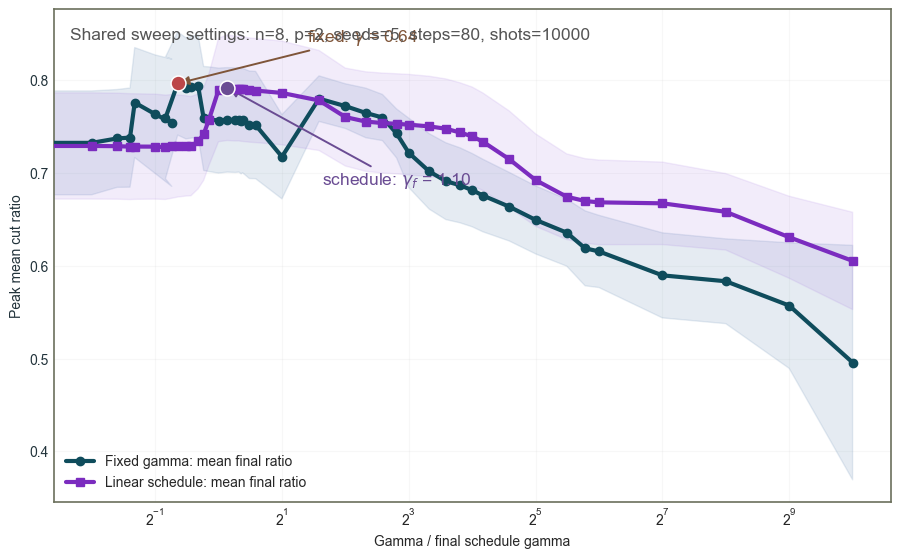

In [14]:
# compare_output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.png"
# compare_output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_fixed_vs_schedule_peak_gamma_sweep.pdf"

gamma_sweep_config = {**RUN_CONFIG, "shots": 10000}
# gamma_plot_values = np.array([0.0, 0.25, 0.33, 0.4, 0.5, 0.56, 0.64, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.25, 1.28, 1.3, 1.4, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 24.0, 32.0, 45.0, 55.0, 64.0])
# tail_window = 10

fixed_best_idx = gamma_summary_df["mean_final_ratio"].idxmax()
fixed_best_gamma = float(gamma_summary_df.loc[fixed_best_idx, "gamma_plot"])
fixed_best_ratio = float(gamma_summary_df.loc[fixed_best_idx, "mean_final_ratio"])

schedule_best_idx = schedule_gamma_summary_df["mean_final_ratio"].idxmax()
schedule_best_gamma = float(schedule_gamma_summary_df.loc[schedule_best_idx, "gamma_plot"])
schedule_best_ratio = float(schedule_gamma_summary_df.loc[schedule_best_idx, "mean_final_ratio"])

compare_y_min = max(
    0.30,
    min(
        float(gamma_summary_df["mean_final_ratio"].min()),
        float(schedule_gamma_summary_df["mean_final_ratio"].min()),
    ) - 0.05,
)
compare_y_max = min(
    0.98,
    max(
        float(gamma_summary_df["mean_final_ratio"].max()),
        float(schedule_gamma_summary_df["mean_final_ratio"].max()),
    ) + 0.03,
)

fig, ax = plt.subplots(figsize=(10.8, 6.4))
# fig.patch.set_facecolor("#fcf7ef")
# ax.set_facecolor("#f7f1e8")

ax.fill_between(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"] - gamma_summary_df["sem_final_ratio"],
    gamma_summary_df["mean_final_ratio"] + gamma_summary_df["sem_final_ratio"],
    color="#4C78A8",
    alpha=0.14,
    zorder=1,
)
ax.fill_between(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"] - schedule_gamma_summary_df["sem_final_ratio"],
    schedule_gamma_summary_df["mean_final_ratio"] + schedule_gamma_summary_df["sem_final_ratio"],
    color="#9C6ADE",
    alpha=0.12,
    zorder=1,
)

ax.plot(
    gamma_summary_df["gamma_plot"],
    gamma_summary_df["mean_final_ratio"],
    color="#0f4c5c",
    linewidth=3.0,
    marker="o",
    markersize=6.0,
    zorder=3,
    label="Fixed gamma: mean final ratio",
)
ax.plot(
    schedule_gamma_summary_df["gamma_plot"],
    schedule_gamma_summary_df["mean_final_ratio"],
    color="#7b2cbf",
    linewidth=3.0,
    marker="s",
    markersize=5.6,
    zorder=4,
    label="Linear schedule: mean final ratio",
)

ax.scatter([fixed_best_gamma], [fixed_best_ratio], color="#bc4749", s=115, edgecolor="white", linewidth=1.1, zorder=5)
ax.scatter([schedule_best_gamma], [schedule_best_ratio], color="#6a4c93", s=115, edgecolor="white", linewidth=1.1, zorder=5)

ax.annotate(
    f"fixed: $\\gamma$ = {fixed_best_gamma:.2f}",
    xy=(fixed_best_gamma, fixed_best_ratio),
    xytext=(fixed_best_gamma + 2, fixed_best_ratio + 0.05),
    fontsize=12.5,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.4},
)
ax.annotate(
    f"schedule: $\\gamma_f$ = {schedule_best_gamma:.2f}",
    xy=(schedule_best_gamma, schedule_best_ratio),
    xytext=(schedule_best_gamma + 2, max(compare_y_min + 0.03, schedule_best_ratio - 0.1)),
    fontsize=12.5,
    color="#6a4c93",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#6a4c93", "lw": 1.4},
)

ax.text(
    0.02,
    0.94,
    f"Shared sweep settings: n={gamma_sweep_config['sizes'][0]}, p={gamma_sweep_config['depths'][0]}, seeds={len(gamma_sweep_config['seeds'])}, steps={gamma_sweep_config['steps']}, shots={gamma_sweep_config['shots']}",
    transform=ax.transAxes,
    fontsize=12.5,
    color="#555555",
)
ax.set_xlabel("Gamma / final schedule gamma")
ax.set_xscale('log', base=2)
ax.set_ylabel("Peak mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
# ax.set_xlim(0, 70)
# ax.set_ylim(compare_y_min, compare_y_max + 0.04)
ax.grid(alpha=0.14)
ax.legend(frameon=False, loc="lower left")
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# fig.savefig(compare_output_png, bbox_inches="tight", dpi=240)
# fig.savefig(compare_output_pdf, bbox_inches="tight")
plt.show()

# print(f"Saved {compare_output_png}")
# print(f"Saved {compare_output_pdf}")


1. Expectation over various random graphs. Pick up 5 good graph examples and do average.
2. Pick and final. a) final. b). reduce the optimization step to 40.
3. add more small gammas and very large gammas.

4. x-axis can be plotted in log or exp scale.
5. Consider different shot budgets.

6. n=14, p=3

